# GRÁFICA DE DISTRIBUCIÓN DE ENERGÍA POR CONTINENTE

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric


In [25]:


# Create a continent mapping
continent_map = {
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Cote d\'Ivoire', 'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia','Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand', 'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'North America': ['Canada', 'Greenland', 'Mexico', 'United States'],
    'Oceania': ['Australia', 'Fiji', 'New Zealand', 'Papua New Guinea'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
}


In [3]:
dataset = pd.read_csv ("World Energy Consumption.csv")

In [4]:
col_electricity = ['low_carbon_electricity',
            'nuclear_electricity',
            'oil_electricity',
            'other_renewable_electricity',
            'other_renewable_exc_biofuel_electricity',
            'solar_electricity',
            'wind_electricity',
            'fossil_electricity',
            'gas_electricity',
            'hydro_electricity',
            'biofuel_electricity',
            'coal_electricity']
col_cons =['biofuel_consumption',
           'coal_consumption',
           'fossil_fuel_consumption',
           'gas_consumption',
           'hydro_consumption',
           'low_carbon_consumption',
           'nuclear_consumption',
           'oil_consumption',
           'solar_consumption']

In [15]:
#segundo dataframe que incluye columna con datos de consumo / dato exogeno

dataset_exog_1= dataset.groupby(['year','country'])[col_electricity].sum().sum(axis=1).to_frame('electricity_generation').reset_index("country")
dataset_exog_2 = dataset.groupby(["year", "country"])[col_cons].sum().sum(axis=1).to_frame('electricty_consumption').reset_index('country')

dataset_exog = pd.merge(dataset_exog_1, dataset_exog_2, on=['year', 'country'])

dataset_exog['continent'] = dataset_exog['country'].map(lambda x: next((k for k, v in continent_map.items() if x in v), None))
dataset_exog = dataset_exog[dataset_exog['continent'].notna()]

data_1986 = dataset_exog[dataset_exog.index>1985].reset_index()

In [26]:
data_1986.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5657 entries, 0 to 5656
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    5657 non-null   int64  
 1   country                 5657 non-null   object 
 2   electricity_generation  5657 non-null   float64
 3   electricty_consumption  5657 non-null   float64
 4   continent               5657 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 221.1+ KB


In [ ]:
data_pais = data_pais[data_pais.index>=1985]
data_paraguay  = data_pais[data_pais['country']=='Paraguay'].reset_index()
data_paraguay

In [ ]:
dataset_norteamerica_2 = data_exog[data_exog['continent']=='North America']
dataset_norteamerica_2= dataset_norteamerica_2.reset_index()
dataset_norteamerica_2.drop(columns='continent',inplace=True)
dataset_norteamerica_2

In [ ]:
europa_norteamerica(dataset_norteamerica_2)

## Prophet por pais o continente

In [35]:
# PROPHET CON DATOS EXOGENOS

def prophet(dato,lugar):
    if lugar in dato['continent'].values:
        dato = dato.groupby(['year','continent'])[['electricity_generation', 'electricty_consumption']].sum().reset_index()
        dato = dato[dato['continent']==lugar]
        print(dato)
    elif lugar in dato['country'].values:
        dato = dato.groupby(['year','country'])[['electricity_generation', 'electricty_consumption']].sum().reset_index()
        dato = dato[dato['country']==lugar]
        print(dato)
    else:
        return None
    # Crear una copia temporal de los datos
    prophet_data = dato.copy()
    prophet_data['ds'] = pd.to_datetime(prophet_data['year'], format='%Y')
    prophet_data['y'] = prophet_data['electricity_generation']

    #prophet_data['electricty_consumption'] = prophet_data['electricty_consumption']

    # Definir la grilla de parámetros para optimización
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5, 1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
        'seasonality_mode': ['additive', 'multiplicative']
    }

    # Generar todas las combinaciones de parámetros
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    rmses = []

    # Usar el 70% de los datos para entrenamiento
    train_size = int(len(prophet_data) * 0.7)
    train_data = prophet_data.iloc[:train_size]
    test_data = prophet_data.iloc[train_size:]

    print("Finding best parameters...")
    best_rmse = float('inf')
    best_params = None

    for params in all_params:
        # Crear y ajustar el modelo con cada combinación de parámetros
        model = Prophet(
            yearly_seasonality=True,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            seasonality_mode=params['seasonality_mode']
        )
        model.add_regressor('electricty_consumption')
        model.fit(train_data)

        # Generar el dataframe futuro para el periodo de test
        future = model.make_future_dataframe(periods=len(test_data), freq='Y')
        # Incorporar la variable externa en el futuro
        future = future.merge(prophet_data[['ds', 'electricty_consumption']], on='ds', how='left')
        # Rellenar valores faltantes (por ejemplo, usando el último valor observado)
        future['electricty_consumption'] = future['electricty_consumption'].fillna(method='ffill')

        forecast = model.predict(future)

        # Calcular el error para el periodo de test
        test_predictions = forecast.iloc[-len(test_data):]
        rmse = np.sqrt(mean_squared_error(test_data['y'], test_predictions['yhat']))
        rmses.append(rmse)

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    print("\nBest parameters:")
    for param, value in best_params.items():
        print(f"{param}: {value}")
    print(f"Best RMSE: {best_rmse:.2f}")

    # Ajustar el modelo final con los mejores parámetros
    final_model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )
    final_model.add_regressor('electricty_consumption')
    final_model.fit(prophet_data)

    # Crear el dataframe futuro para 5 periodos adicionales
    future = final_model.make_future_dataframe(periods=5, freq='Y')
    # Incorporar el regressor en el dataframe futuro
    future = future.merge(prophet_data[['ds', 'electricty_consumption']], on='ds', how='left')
    future['electricty_consumption'] = future['electricty_consumption'].fillna(method='ffill')

    forecast = final_model.predict(future)


    # Create visualization plots
    plt.figure(figsize=(20, 12))


    # Print additional metrics for test set
    mae = mean_absolute_error(test_data['y'], test_predictions['yhat'])
    mape = np.mean(np.abs((test_data['y'] - test_predictions['yhat']) / test_data['y'])) * 100

    f_cv = cross_validation(final_model, initial='730 days', period='365 days', horizon='365 days')
    print(f_cv)


    print("\nTest Set Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {best_rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    plt.figure(figsize=(10, 6))

    # Datos reales
    plt.plot(prophet_data['ds'], prophet_data['y'], 'r-', label="Datos reales")

    # Predicción
    plt.plot(forecast['ds'], forecast['yhat'], 'b-', label="Predicción")

    # Intervalo de confianza
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     color='blue', alpha=0.2, label="Intervalo de confianza")

    # Etiquetas y título
    plt.xlabel("Año")
    plt.ylabel("Generación de electricidad")
    plt.title("Predicción de Generación de Electricidad con Prophet")
    plt.legend()
    plt.grid()

    plt.show()

    df_p = performance_metrics(f_cv)
    print(df_p.head(10))
    fig = plot_cross_validation_metric(f_cv, metric='mape')

15:47:08 - cmdstanpy - INFO - Chain [1] start processing
15:47:08 - cmdstanpy - INFO - Chain [1] done processing
15:47:08 - cmdstanpy - INFO - Chain [1] start processing


     year continent  electricity_generation  electricty_consumption
2    1986    Europe                6548.897               65006.231
8    1987    Europe                6804.285               66475.682
14   1988    Europe                6994.117               67218.872
20   1989    Europe                7132.511               67133.190
26   1990    Europe                8257.678               67815.719
32   1991    Europe                8261.587               67113.532
38   1992    Europe                8062.355               64683.764
44   1993    Europe                7924.978               62461.332
50   1994    Europe                7792.639               59975.938
56   1995    Europe                7905.884               59742.992
62   1996    Europe                8008.670               60310.233
68   1997    Europe                8029.616               59297.185
74   1998    Europe                8146.096               59607.973
80   1999    Europe                8259.832     

15:47:08 - cmdstanpy - INFO - Chain [1] done processing
15:47:08 - cmdstanpy - INFO - Chain [1] start processing
15:47:08 - cmdstanpy - INFO - Chain [1] done processing
15:47:08 - cmdstanpy - INFO - Chain [1] start processing
15:47:09 - cmdstanpy - INFO - Chain [1] done processing
15:47:09 - cmdstanpy - INFO - Chain [1] start processing
15:47:09 - cmdstanpy - INFO - Chain [1] done processing
15:47:09 - cmdstanpy - INFO - Chain [1] start processing
15:47:09 - cmdstanpy - INFO - Chain [1] done processing
15:47:09 - cmdstanpy - INFO - Chain [1] start processing
15:47:09 - cmdstanpy - INFO - Chain [1] done processing
15:47:09 - cmdstanpy - INFO - Chain [1] start processing
15:47:09 - cmdstanpy - INFO - Chain [1] done processing
15:47:09 - cmdstanpy - INFO - Chain [1] start processing
15:47:09 - cmdstanpy - INFO - Chain [1] done processing
15:47:09 - cmdstanpy - INFO - Chain [1] start processing
15:47:09 - cmdstanpy - INFO - Chain [1] done processing
15:47:09 - cmdstanpy - INFO - Chain [1] 


Best parameters:
changepoint_prior_scale: 0.1
seasonality_prior_scale: 10.0
seasonality_mode: additive
Best RMSE: 642.95


  0%|          | 0/34 [00:00<?, ?it/s]

15:47:16 - cmdstanpy - INFO - Chain [1] start processing
15:47:17 - cmdstanpy - INFO - Chain [1] done processing
15:47:17 - cmdstanpy - INFO - Chain [1] start processing
15:47:17 - cmdstanpy - INFO - Chain [1] done processing
15:47:17 - cmdstanpy - INFO - Chain [1] start processing
15:47:17 - cmdstanpy - INFO - Chain [1] done processing
15:47:17 - cmdstanpy - INFO - Chain [1] start processing
15:47:17 - cmdstanpy - INFO - Chain [1] done processing
15:47:17 - cmdstanpy - INFO - Chain [1] start processing
15:47:17 - cmdstanpy - INFO - Chain [1] done processing
15:47:17 - cmdstanpy - INFO - Chain [1] start processing
15:47:17 - cmdstanpy - INFO - Chain [1] done processing
15:47:17 - cmdstanpy - INFO - Chain [1] start processing
15:47:18 - cmdstanpy - INFO - Chain [1] done processing
15:47:18 - cmdstanpy - INFO - Chain [1] start processing
15:47:18 - cmdstanpy - INFO - Chain [1] done processing
15:47:18 - cmdstanpy - INFO - Chain [1] start processing
15:47:18 - cmdstanpy - INFO - Chain [1]

           ds         yhat   yhat_lower    yhat_upper         y     cutoff
0  1989-01-01  7629.319201  7617.716175   7639.850219  7132.511 1988-01-10
1  1990-01-01  7308.019931  7262.129659   7347.764250  8257.678 1989-01-09
2  1991-01-01  9558.164932  9505.592431   9611.249435  8261.587 1990-01-09
3  1992-01-01  8281.422089  8103.483419   8475.874958  8062.355 1991-01-09
4  1993-01-01  8067.985600  7914.476400   8220.654177  7924.978 1992-01-09
5  1994-01-01  8241.802220  8128.389910   8359.858470  7792.639 1993-01-08
6  1995-01-01  8241.006922  8112.300121   8379.971538  7905.884 1994-01-08
7  1996-01-01  8089.955216  7938.671724   8233.527560  8008.670 1995-01-08
8  1997-01-01  8042.557308  7867.578258   8208.312143  8029.616 1996-01-08
9  1998-01-01  8489.795853  8327.252375   8652.349360  8146.096 1997-01-07
10 1999-01-01  8412.226755  8234.434861   8581.873289  8259.832 1998-01-07
11 2000-01-01  8324.655683  8156.538415   8486.156855  8498.450 1999-01-07
12 2001-01-01  8642.51155

<Figure size 2000x1200 with 0 Axes>

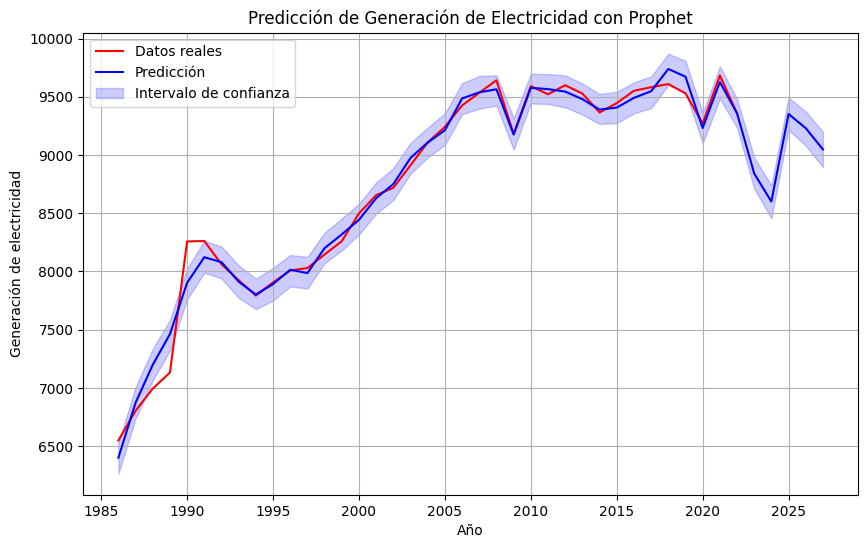

   horizon            mse        rmse         mae      mape     mdape  \
0 357 days  719443.390123  848.200088  740.527823  0.092192  0.092329   
1 358 days   85278.357839  292.024584  252.144740  0.032056  0.030217   
2 359 days   42931.423015  207.198994  170.707558  0.020676  0.019450   
3 360 days   12190.354306  110.409938   95.176082  0.010743  0.011664   
4 361 days    9758.562016   98.785434   85.175303  0.008983  0.010090   
5 362 days    6251.676140   79.067542   58.701241  0.006151  0.004738   
6 363 days   12318.823671  110.990196   92.920805  0.009856  0.007625   
7 364 days   29363.212002  171.356972  158.282960  0.016612  0.014009   
8 365 days   14345.051403  119.770829   93.291427  0.009729  0.010993   

      smape  coverage  
0  0.090415  0.000000  
1  0.031379  0.500000  
2  0.020468  0.500000  
3  0.010684  1.000000  
4  0.008991  1.000000  
5  0.006117  1.000000  
6  0.009787  0.750000  
7  0.016483  0.500000  
8  0.009710  0.833333  


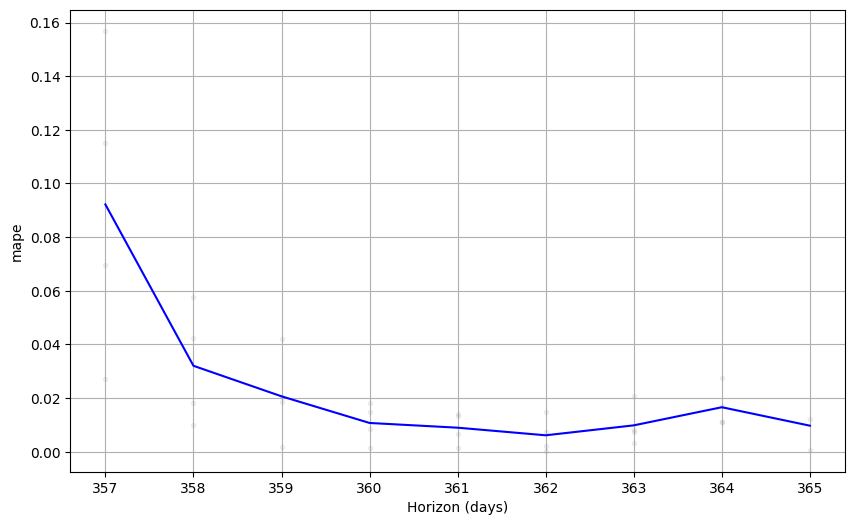

In [39]:
lugar='Europe'
prophet(data_1986,lugar)


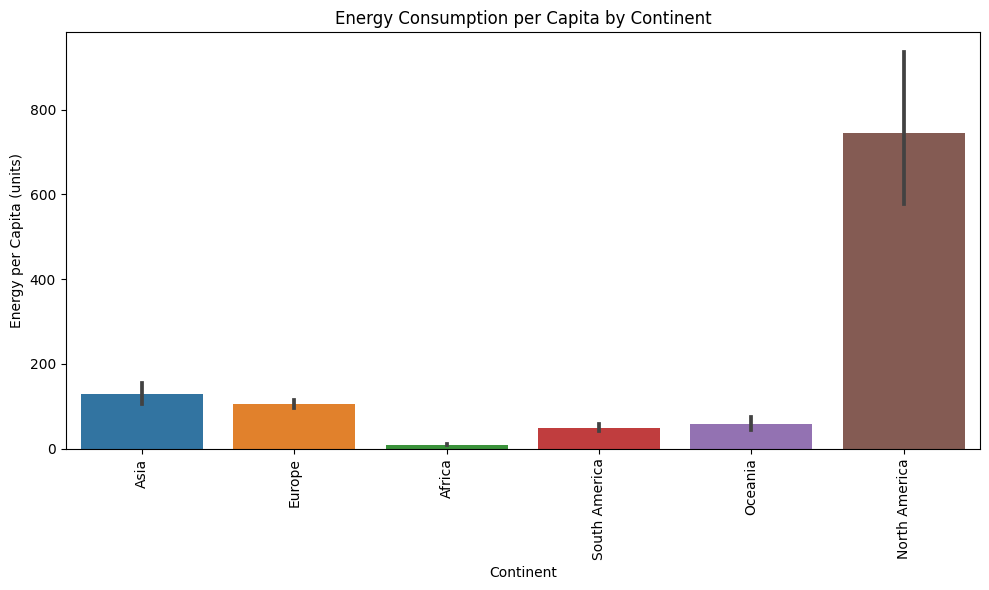

In [ ]:
dataset = dataset.groupby(['year','country'])[col_electricity].sum().sum(axis=1).to_frame('electricity_generation').reset_index("country")

# Filter out rows with missing 'energy_per_capita' values
dataset_filtered = dataset[dataset['electricity_generation'].notna()]

# Add a 'continent' column to the dataset
dataset_filtered['continent'] = dataset_filtered['country'].map(lambda x: next((k for k, v in continent_map.items() if x in v), None))
dataset_filtered = dataset_filtered[dataset_filtered['continent'].notna()]

# Plot energy consumption per capita across continents
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=dataset_filtered, x='continent', y='electricity_generation', ax=ax)
ax.set_title('Energy Consumption per Capita by Continent')
ax.set_xlabel('Continent')
ax.set_ylabel('Energy per Capita (units)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# FILTROS PARA TOMAR DESDE 1986

In [59]:
dataset_continentes = dataset_filtered.groupby(["year","continent"])["electricity_generation"].sum().to_frame('electricity_generation').reset_index("continent")
dataset_continentes_filt = dataset_continentes[dataset_continentes["electricity_generation"]>0]
dataset_continentes_filt = dataset_continentes_filt[dataset_continentes_filt.index>=1986]
dataset_continentes_filt

,continent,electricity_generation
year,,
1986,Africa,350.398
1986,Asia,3555.145
1986,Europe,6548.897
1986,North America,6487.563
1986,Oceania,283.132
...,...,...
2022,Asia,31197.503
2022,Europe,9356.613
2022,North America,10662.530


## DATOS EUROPA

In [48]:
dataset_europa = dataset_continentes_filt[dataset_continentes_filt["continent"]=="Europe"]
dataset_europa.drop(columns=["continent"])
dataset_europa = dataset_europa.reset_index()

## DATOS NORTEAMERICA

In [49]:
dataset_norteamerica = dataset_continentes_filt[dataset_continentes_filt["continent"]=="North America"]
dataset_norteamerica = dataset_norteamerica.reset_index()
dataset_norteamerica =dataset_norteamerica.drop(columns=["continent"])


# MODELO PROPHET

In [ ]:

def europa_norteamerica (dato):
    # Prepare data for Prophet
    prophet_data = dato.copy()
    prophet_data['ds'] = pd.to_datetime(prophet_data['year'], format='%Y')
    prophet_data['y'] = prophet_data['electricity_generation']

    # Define parameter grid for optimization
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5,1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0,10.0],
        'seasonality_mode': ['additive', 'multiplicative']
    }

    # Generate all combinations of parameters
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    rmses = []

    # Use 80% of data for training
    train_size = int(len(prophet_data) * 0.7)
    train_data = prophet_data[:train_size]
    test_data = prophet_data[train_size:]

    # Evaluate all parameters
    print("Finding best parameters...")
    best_rmse = float('inf')
    best_params = None

    for params in all_params:
        # Create and fit model
        model = Prophet(
            yearly_seasonality=True,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            seasonality_mode=params['seasonality_mode']
        )

        model.fit(train_data)

        # Make predictions for test period
        future = model.make_future_dataframe(periods=len(test_data), freq='Y')
        forecast = model.predict(future)

        # Calculate error
        test_predictions = forecast.iloc[-len(test_data):]
        rmse = np.sqrt(mean_squared_error(test_data['y'], test_predictions['yhat']))
        rmses.append(rmse)

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    print("\nBest parameters:")
    for param, value in best_params.items():
        print(f"{param}: {value}")
    print(f"Best RMSE: {best_rmse:.2f}")

    # Fit final model with best parameters
    final_model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )
    final_model.fit(prophet_data)

    # Make future predictions
    future = final_model.make_future_dataframe(periods=5, freq='Y')
    forecast = final_model.predict(future)

    # Create visualization plots
    plt.figure(figsize=(20, 12))

    """# Plot 1: Original data with forecast
    plt.subplot(2, 2, 1)
    fig1 = final_model.plot(forecast)
    plt.title('Prophet Forecast with Best Parameters')
    plt.xlabel('Year')
    plt.ylabel('Generation')

    # Plot 2: Components (in separate figure)
    fig2 = final_model.plot_components(forecast)
    plt.close(fig2)  # Close the components figure as we'll show it separately

    # Plot 3: Changepoints
    plt.subplot(2, 2, 3)
    final_model.plot(forecast)
    deltas = final_model.params['delta'][0]
    for cp in final_model.changepoints:
        plt.axvline(cp, color='r', alpha=0.2)
    plt.title('Changepoints')

    # Plot 4: Validation
    plt.subplot(2, 2, 4)
    plt.plot(test_data['ds'], test_data['y'], 'r.', label='Actual')
    plt.plot(test_predictions['ds'], test_predictions['yhat'], 'b-', label='Predicted')
    plt.fill_between(test_predictions['ds'],
                     test_predictions['yhat_lower'],
                     test_predictions['yhat_upper'],
                     color='b', alpha=0.2)
    plt.title('Model Validation on Test Set')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Show components plot separately
    plt.figure(figsize=(12, 8))
    final_model.plot_components(forecast)
    plt.show()

    # Print forecast for next 5 years
    future_forecast = forecast[forecast['ds'].dt.year > 2022][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    print("\nForecast for next 5 years:")
    print(future_forecast.round(2))"""

    # Print additional metrics for test set
    mae = mean_absolute_error(test_data['y'], test_predictions['yhat'])
    mape = np.mean(np.abs((test_data['y'] - test_predictions['yhat']) / test_data['y'])) * 100

    f_cv = cross_validation(final_model, initial='730 days', period='365 days', horizon='365 days')
    print(f_cv)


    print("\nTest Set Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {best_rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    plt.figure(figsize=(10, 6))

    # Datos reales
    plt.plot(prophet_data['ds'], prophet_data['y'], 'r-', label="Datos reales")

    # Predicción
    plt.plot(forecast['ds'], forecast['yhat'], 'b-', label="Predicción")

    # Intervalo de confianza
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     color='blue', alpha=0.2, label="Intervalo de confianza")

    # Etiquetas y título
    plt.xlabel("Año")
    plt.ylabel("Generación de electricidad")
    plt.title("Predicción de Generación de Electricidad con Prophet")
    plt.legend()
    plt.grid()

    plt.show()

    df_p = performance_metrics(f_cv)
    print(df_p.head(10))
    fig = plot_cross_validation_metric(f_cv, metric='mape')

# DESCOMENTAR Y CORRER EUROPA O NORTEAMERICA

16:46:13 - cmdstanpy - INFO - Chain [1] start processing
16:46:13 - cmdstanpy - INFO - Chain [1] done processing


Finding best parameters...


16:46:13 - cmdstanpy - INFO - Chain [1] start processing
16:46:13 - cmdstanpy - INFO - Chain [1] done processing
16:46:14 - cmdstanpy - INFO - Chain [1] start processing
16:46:14 - cmdstanpy - INFO - Chain [1] done processing
16:46:14 - cmdstanpy - INFO - Chain [1] start processing
16:46:14 - cmdstanpy - INFO - Chain [1] done processing
16:46:14 - cmdstanpy - INFO - Chain [1] start processing
16:46:16 - cmdstanpy - INFO - Chain [1] done processing
16:46:16 - cmdstanpy - INFO - Chain [1] start processing
16:46:25 - cmdstanpy - INFO - Chain [1] done processing
16:46:25 - cmdstanpy - INFO - Chain [1] start processing
16:46:26 - cmdstanpy - INFO - Chain [1] done processing
16:46:26 - cmdstanpy - INFO - Chain [1] start processing
16:46:26 - cmdstanpy - INFO - Chain [1] done processing
16:46:26 - cmdstanpy - INFO - Chain [1] start processing
16:46:26 - cmdstanpy - INFO - Chain [1] done processing
16:46:26 - cmdstanpy - INFO - Chain [1] start processing
16:46:26 - cmdstanpy - INFO - Chain [1]


Best parameters:
changepoint_prior_scale: 0.5
seasonality_prior_scale: 10.0
seasonality_mode: multiplicative
Best RMSE: 241.05


16:46:40 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/34 [00:00<?, ?it/s]

16:46:40 - cmdstanpy - INFO - Chain [1] start processing
16:46:43 - cmdstanpy - INFO - Chain [1] done processing
16:46:43 - cmdstanpy - INFO - Chain [1] start processing
16:46:46 - cmdstanpy - INFO - Chain [1] done processing
16:46:46 - cmdstanpy - INFO - Chain [1] start processing
16:46:49 - cmdstanpy - INFO - Chain [1] done processing
16:46:49 - cmdstanpy - INFO - Chain [1] start processing
16:46:49 - cmdstanpy - INFO - Chain [1] done processing
16:46:49 - cmdstanpy - INFO - Chain [1] start processing
16:46:53 - cmdstanpy - INFO - Chain [1] done processing
16:46:54 - cmdstanpy - INFO - Chain [1] start processing
16:46:58 - cmdstanpy - INFO - Chain [1] done processing
16:46:58 - cmdstanpy - INFO - Chain [1] start processing
16:47:03 - cmdstanpy - INFO - Chain [1] done processing
16:47:03 - cmdstanpy - INFO - Chain [1] start processing
16:47:07 - cmdstanpy - INFO - Chain [1] done processing
16:47:08 - cmdstanpy - INFO - Chain [1] start processing
16:47:08 - cmdstanpy - INFO - Chain [1]

           ds         yhat   yhat_lower   yhat_upper         y     cutoff
0  1989-01-01  7090.368633  7060.828017  7114.258769  7132.511 1988-01-10
1  1990-01-01  7330.404066  7312.430357  7350.627408  8257.678 1989-01-09
2  1991-01-01  9396.618884  9195.954410  9599.228391  8261.587 1990-01-09
3  1992-01-01  8335.853979  8149.253879  8495.551844  8062.355 1991-01-09
4  1993-01-01  7402.579058  7178.986667  7633.990973  7924.978 1992-01-09
5  1994-01-01  7956.407760  7702.771168  8228.413161  7792.639 1993-01-08
6  1995-01-01  7608.786533  7358.217444  7882.842723  7905.884 1994-01-08
7  1996-01-01  8275.885644  7889.473319  8697.239252  8008.670 1995-01-08
8  1997-01-01  7861.143799  7566.568552  8129.202523  8029.616 1996-01-08
9  1998-01-01  8152.837995  7932.873156  8358.217067  8146.096 1997-01-07
10 1999-01-01  8256.252769  8028.664361  8459.335948  8259.832 1998-01-07
11 2000-01-01  8370.003797  8168.193391  8543.400435  8498.450 1999-01-07
12 2001-01-01  8622.393475  8422.96069

<Figure size 2000x1200 with 0 Axes>

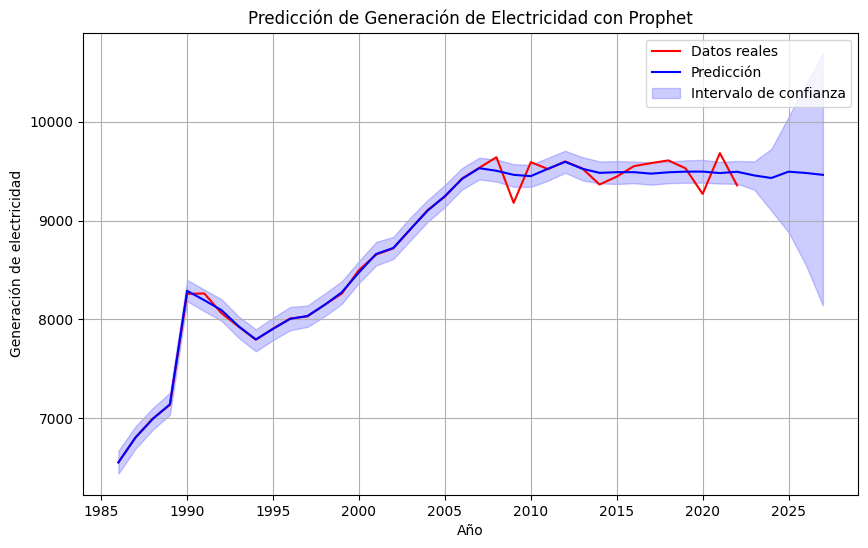

16:47:34 - cmdstanpy - INFO - Chain [1] start processing


   horizon            mse        rmse         mae      mape     mdape  \
0 357 days  556177.998837  745.773423  594.486791  0.072378  0.073108   
1 358 days  114847.991473  338.892301  312.620203  0.039470  0.035473   
2 359 days   11234.893755  105.994782   76.809908  0.009339  0.007971   
3 360 days    1977.151827   44.465175   42.331720  0.004764  0.004621   
4 361 days    5894.648530   76.776614   63.902394  0.006713  0.006368   
5 362 days  117356.094586  342.572758  238.693725  0.025682  0.012125   
6 363 days   26421.884488  162.548099  143.797384  0.015205  0.016604   
7 364 days   55961.303868  236.561417  205.532003  0.021773  0.020809   
8 365 days   43075.900588  207.547345  190.761488  0.020169  0.025459   

      smape  coverage  
0  0.071703  0.000000  
1  0.040020  0.500000  
2  0.009423  1.000000  
3  0.004767  1.000000  
4  0.006707  1.000000  
5  0.025022  0.750000  
6  0.015208  0.500000  
7  0.021678  0.250000  
8  0.020060  0.416667  
Finding best parameters...


16:47:34 - cmdstanpy - INFO - Chain [1] done processing
16:47:34 - cmdstanpy - INFO - Chain [1] start processing
16:47:34 - cmdstanpy - INFO - Chain [1] done processing
16:47:34 - cmdstanpy - INFO - Chain [1] start processing
16:47:34 - cmdstanpy - INFO - Chain [1] done processing
16:47:34 - cmdstanpy - INFO - Chain [1] start processing
16:47:35 - cmdstanpy - INFO - Chain [1] done processing
16:47:35 - cmdstanpy - INFO - Chain [1] start processing
16:47:35 - cmdstanpy - INFO - Chain [1] done processing
16:47:35 - cmdstanpy - INFO - Chain [1] start processing
16:47:35 - cmdstanpy - INFO - Chain [1] done processing
16:47:35 - cmdstanpy - INFO - Chain [1] start processing
16:47:35 - cmdstanpy - INFO - Chain [1] done processing
16:47:35 - cmdstanpy - INFO - Chain [1] start processing
16:47:36 - cmdstanpy - INFO - Chain [1] done processing
16:47:36 - cmdstanpy - INFO - Chain [1] start processing
16:47:36 - cmdstanpy - INFO - Chain [1] done processing
16:47:36 - cmdstanpy - INFO - Chain [1] 


Best parameters:
changepoint_prior_scale: 0.5
seasonality_prior_scale: 0.1
seasonality_mode: additive
Best RMSE: 178.57


16:47:50 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/34 [00:00<?, ?it/s]

16:47:50 - cmdstanpy - INFO - Chain [1] start processing
16:47:53 - cmdstanpy - INFO - Chain [1] done processing
16:47:53 - cmdstanpy - INFO - Chain [1] start processing
16:47:57 - cmdstanpy - INFO - Chain [1] done processing
16:47:57 - cmdstanpy - INFO - Chain [1] start processing
16:48:00 - cmdstanpy - INFO - Chain [1] done processing
16:48:00 - cmdstanpy - INFO - Chain [1] start processing
16:48:00 - cmdstanpy - INFO - Chain [1] done processing
16:48:01 - cmdstanpy - INFO - Chain [1] start processing
16:48:01 - cmdstanpy - INFO - Chain [1] done processing
16:48:01 - cmdstanpy - INFO - Chain [1] start processing
16:48:05 - cmdstanpy - INFO - Chain [1] done processing
16:48:05 - cmdstanpy - INFO - Chain [1] start processing
16:48:09 - cmdstanpy - INFO - Chain [1] done processing
16:48:09 - cmdstanpy - INFO - Chain [1] start processing
16:48:09 - cmdstanpy - INFO - Chain [1] done processing
16:48:09 - cmdstanpy - INFO - Chain [1] start processing
16:48:09 - cmdstanpy - INFO - Chain [1]

           ds          yhat    yhat_lower    yhat_upper          y     cutoff
0  1989-01-01   7376.813591   7352.140635   7401.115586   7537.124 1988-01-10
1  1990-01-01   7943.529318   7902.429101   7984.094318   7640.277 1989-01-09
2  1991-01-01   7742.168217   7669.831262   7816.854270   7786.258 1990-01-09
3  1992-01-01   7905.041755   7859.304472   7944.749453   7842.673 1991-01-09
4  1993-01-01   8114.920886   8073.081854   8157.597054   8110.909 1992-01-09
5  1994-01-01   8165.891092   8116.310732   8216.073629   8287.688 1993-01-08
6  1995-01-01   8463.437926   8390.642299   8526.643206   8520.539 1994-01-08
7  1996-01-01   8717.788115   8661.962941   8773.622770   8751.178 1995-01-08
8  1997-01-01   9116.336793   9070.567678   9168.496146   8876.033 1996-01-08
9  1998-01-01   9111.069896   8991.418518   9236.469513   9160.973 1997-01-07
10 1999-01-01   9405.848957   9299.780773   9526.926480   9367.515 1998-01-07
11 2000-01-01   9622.327910   9536.520826   9727.649653   9265.1

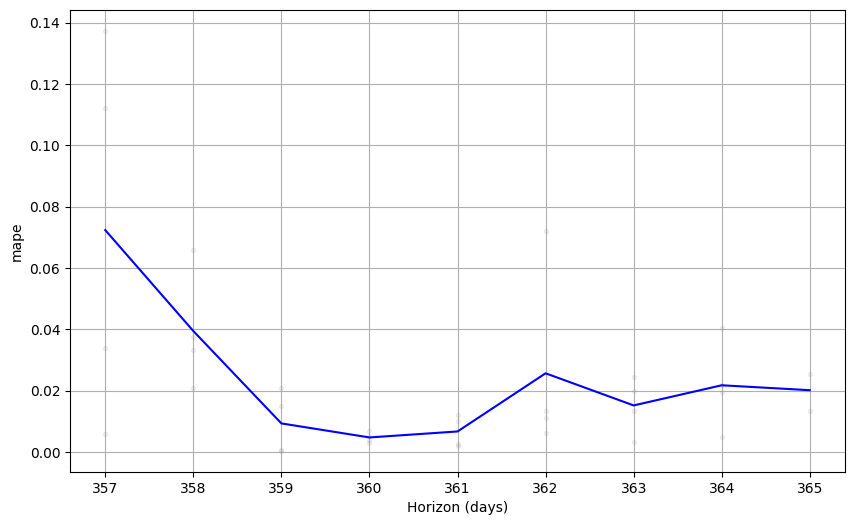

<Figure size 2000x1200 with 0 Axes>

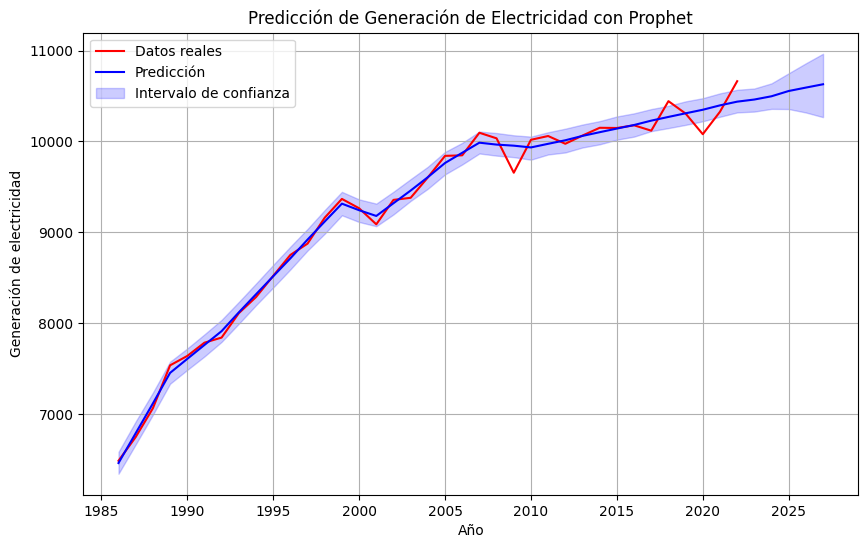

   horizon            mse        rmse         mae      mape     mdape  \
0 357 days   30873.791577  175.709395  142.505316  0.018644  0.014611   
1 358 days    4806.499763   69.328924   54.074938  0.006427  0.005259   
2 359 days   47325.804068  217.544947  171.437191  0.018792  0.016260   
3 360 days   80415.507756  283.576282  211.748781  0.022899  0.014927   
4 361 days   47061.117567  216.935745  179.807148  0.018166  0.015361   
5 362 days  124436.784793  352.755985  224.071967  0.023019  0.008763   
6 363 days    9179.652627   95.810504   83.233251  0.008220  0.009725   
7 364 days   44844.058654  211.764158  182.179607  0.017829  0.018629   
8 365 days   50532.984137  224.795427  176.105120  0.016784  0.030586   

      smape  coverage  
0  0.018504  0.250000  
1  0.006462  0.750000  
2  0.018521  0.500000  
3  0.022568  0.500000  
4  0.018294  0.250000  
5  0.022394  0.750000  
6  0.008250  0.500000  
7  0.017760  0.250000  
8  0.016920  0.416667  


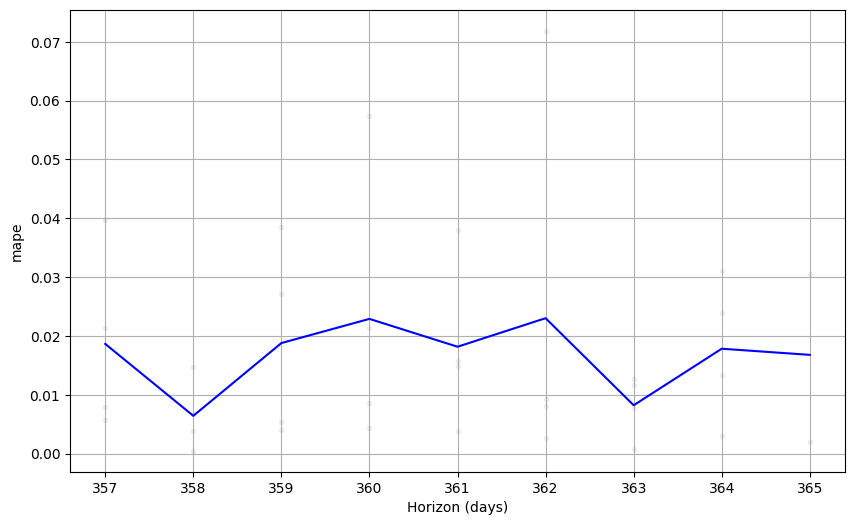

In [56]:
europa_norteamerica(dataset_europa)
europa_norteamerica(dataset_norteamerica)

In [ ]:
def europa_norteamerica_2 (dato):
    # Prepare data for Prophet
    prophet_data = dato.copy()
    prophet_data['ds'] = pd.to_datetime(prophet_data['year'], format='%Y')
    prophet_data['y'] = prophet_data['electricity_generation']

    param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1,1],
    'seasonality_prior_scale': [0.01, 0.1, 1.0,5, 10.0],
    }

    cutoffs = pd.date_range(start='1990-01-01', end='2021-01-01', freq='Y')

    # Generate all combinations of parameters
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    rmses = []  # Store the RMSEs for each params here

    # Use cross validation to evaluate all parameters
    for params in all_params:
        m = Prophet(**params).fit(prophet_data)  # Fit model with given params
        df_cv = cross_validation(m, cutoffs=cutoffs, horizon='30 days', parallel="processes")
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmses.append(df_p['rmse'].values[0])

    # Find the best parameters
    tuning_results = pd.DataFrame(all_params)
    tuning_results['rmse'] = rmses
    print(tuning_results)

    plt.plot(prophet_data['ds'], prophet_data['y'], 'r-', label="Datos reales")

    # Predicción
    plt.plot(m['ds'], m['yhat'], 'b-', label="Predicción")

    # Intervalo de confianza
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
              color='blue', alpha=0.2, label="Intervalo de confianza")

    # Etiquetas y título
    plt.xlabel("Año")
    plt.ylabel("Generación de electricidad")
    plt.title("Predicción de Generación de Electricidad con Prophet")
    plt.legend()
    plt.grid()
    plt.show()

16:50:52 - cmdstanpy - INFO - Chain [1] start processing
16:50:52 - cmdstanpy - INFO - Chain [1] done processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Chain [1] done processing
16:50:53 - cmdstanpy - INFO - Chain [1] start processing
16:50:53 - cmdstanpy - INFO - Cha

    changepoint_prior_scale  seasonality_prior_scale        rmse
0                    0.0001                    0.001  443.668650
1                    0.0001                    0.010  446.720484
2                    0.0001                    0.100  453.717653
3                    0.0001                    1.000  439.740600
4                    0.0001                    5.000  434.398606
5                    0.0001                   10.000  441.467935
6                    0.0010                    0.001  433.726819
7                    0.0010                    0.010  436.543787
8                    0.0010                    0.100  440.270237
9                    0.0010                    1.000  448.212871
10                   0.0010                    5.000  445.878550
11                   0.0010                   10.000  446.245314
12                   0.0100                    0.001  432.679548
13                   0.0100                    0.010  434.194019
14                   0.01

TypeError: 'Prophet' object is not subscriptable

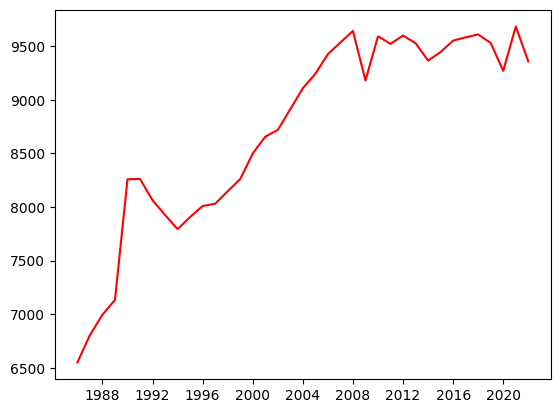

In [58]:
europa_norteamerica_2(dataset_europa)
europa_norteamerica_2(dataset_norteamerica)